# Pattern 4 — Orchestrator–Worker

## The idea in one line
**A planner LLM decides what sub-tasks exist, then dispatches one worker per sub-task, then a synthesizer glues the pieces back together.**

## When to use it
When you can't **predefine** the sub-tasks — the number and shape of them depend on the input:

- Write a report whose sections aren't known until the planner reads the topic
- Edit multiple files across a codebase (the planner decides which files)
- Break a research question into sub-questions that vary every time

This is more flexible than **parallelization** (which has a fixed number of branches).

## When *not* to use it
If the sub-tasks are known in advance → use parallelization. If a single LLM call is enough → don't overengineer.

## The shape of the graph

![Orchestrator–worker workflow](../images/worker.avif)


```
                    ┌─► worker (section 1) ─┐
START ─► orchestrator ─► worker (section 2) ─┼─► synthesizer ─► END
                    └─► worker (section N) ─┘
```

The new piece here is the **`Send` API** — `orchestrator` returns a list of `Send("worker", {...})` objects, which tells LangGraph: *"spawn a worker for each of these payloads."* The number of workers is dynamic.

Two other bits to notice:
- The state uses `Annotated[list, operator.add]` so each worker's output gets **appended** to the list instead of overwriting it.
- Workers get their own small `WorkerState` — they only see their assigned sub-task.


In [10]:
# Setup — run this first in every notebook
import os
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI

load_dotenv()
os.environ["GEMINI_API_KEY"] = os.getenv("GEMINI_API_KEY")

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=1.0,
    max_retries=2,
    google_api_key=os.getenv("GEMINI_API_KEY"),
)


## Example 1 — The docs example (dynamic report writer)

Given a topic, the **planner** proposes a list of sections. Then one worker writes each section. The **synthesizer** concatenates them into the final report.


In [11]:
from typing import Annotated, List
import operator
from typing_extensions import TypedDict
from pydantic import BaseModel, Field
from langchain.messages import SystemMessage, HumanMessage
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send


class Section(BaseModel):
    name: str = Field(description="Name for this section of the report.")
    description: str = Field(description="Brief overview of the topics covered in this section.")


class Sections(BaseModel):
    sections: List[Section] = Field(description="Sections of the report.")


planner = llm.with_structured_output(Sections)


class State(TypedDict):
    topic: str
    sections: list[Section]
    completed_sections: Annotated[list, operator.add]  # workers append here
    final_report: str


class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]


def orchestrator(state: State):
    """Plan the report — produce a list of sections."""
    report_sections = planner.invoke([
        SystemMessage(content="Generate a plan for the report."),
        HumanMessage(content=f"Here is the report topic: {state['topic']}"),
    ])
    return {"sections": report_sections.sections}


def llm_call(state: WorkerState):
    """A worker writes one section of the report."""
    section = llm.invoke([
        SystemMessage(content="Write a report section. Include no preamble. Use markdown."),
        HumanMessage(content=f"Section: {state['section'].name}. Description: {state['section'].description}"),
    ])
    return {"completed_sections": [section.content]}


def synthesizer(state: State):
    """Stitch the completed sections into one report."""
    completed = state["completed_sections"]
    return {"final_report": "\n\n---\n\n".join(completed)}


def assign_workers(state: State):
    """Dispatch one worker per planned section (the Send API)."""
    return [Send("llm_call", {"section": s}) for s in state["sections"]] #inline Loop


orchestrator_builder = StateGraph(State)
orchestrator_builder.add_node("orchestrator", orchestrator)
orchestrator_builder.add_node("llm_call", llm_call)
orchestrator_builder.add_node("synthesizer", synthesizer)

orchestrator_builder.add_edge(START, "orchestrator")
orchestrator_builder.add_conditional_edges("orchestrator", assign_workers, ["llm_call"])
orchestrator_builder.add_edge("llm_call", "synthesizer")
orchestrator_builder.add_edge("synthesizer", END)

graph = orchestrator_builder.compile()


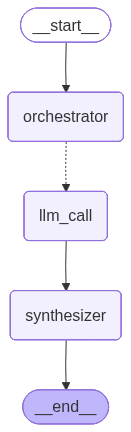

In [12]:
# Visualize the graph (renders as an image in Jupyter)
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))


In [13]:
state = graph.invoke({"topic": "Create a report on LLM scaling laws"})

print("Planned sections:")
for s in state["sections"]:
    print(f" - {s.name}: {s.description}")

print("\n\n=== FINAL REPORT ===\n")
print(state["final_report"][:2000], "...")


Planned sections:
 - Introduction to LLM Scaling Laws: Define LLM scaling laws, their significance in AI research and development, and provide a brief overview of the report's scope.
 - Historical Context and Early Observations: Discuss the origins of scaling law research, including early empirical observations and foundational papers that identified relationships between model performance and various resources.
 - Key Scaling Laws and Empirical Findings: Detail the most prominent scaling laws, such as those by OpenAI, DeepMind (Chinchilla), and others, explaining their methodologies, findings regarding compute, parameters, and data, and the trade-offs involved.
 - Implications for Model Design and Training: Analyze how scaling laws influence practical decisions in LLM development, including optimal resource allocation, model architecture choices, and training strategies to maximize performance efficiency.
 - Challenges, Limitations, and Nuances: Explore scenarios where current scaling

## Example 2 — Real use case: study-guide generator

Same pattern, different domain. Given a subject, the planner proposes **study topics**; workers write a short explainer per topic; the synthesizer builds a study guide.

This is how you build systems whose structure adapts to the input (e.g. exam prep for *any* subject, not just the ones you hardcoded).


In [14]:
class Topic(BaseModel):
    title: str = Field(description="A specific sub-topic within the subject.")
    focus: str = Field(description="What a beginner should learn about this sub-topic.")


class Topics(BaseModel):
    topics: List[Topic] = Field(description="Study topics covering the subject.")


topic_planner = llm.with_structured_output(Topics)


class StudyState(TypedDict):
    subject: str
    topics: list[Topic]
    completed_topics: Annotated[list, operator.add]
    guide: str


class StudyWorkerState(TypedDict):
    topic: Topic
    completed_topics: Annotated[list, operator.add]


def plan_topics(state: StudyState):
    result = topic_planner.invoke([
        SystemMessage(content="Plan 3 to 5 beginner study topics for the subject."),
        HumanMessage(content=f"Subject: {state['subject']}"),
    ])
    return {"topics": result.topics}


def write_topic(state: StudyWorkerState):
    msg = llm.invoke([
        SystemMessage(content="Write a short, beginner-friendly explainer (~150 words) in markdown. Start with an H2 heading."),
        HumanMessage(content=f"Title: {state['topic'].title}\nFocus: {state['topic'].focus}"),
    ])
    return {"completed_topics": [msg.content]}


def build_guide(state: StudyState):
    guide = f"# Study Guide: {state['subject']}\n\n" + "\n\n".join(state["completed_topics"])
    return {"guide": guide}


def dispatch(state: StudyState):
    return [Send("write_topic", {"topic": t}) for t in state["topics"]]


study = StateGraph(StudyState)
study.add_node("plan_topics", plan_topics)
study.add_node("write_topic", write_topic)
study.add_node("build_guide", build_guide)

study.add_edge(START, "plan_topics")
study.add_conditional_edges("plan_topics", dispatch, ["write_topic"])
study.add_edge("write_topic", "build_guide")
study.add_edge("build_guide", END)

graph = study.compile()


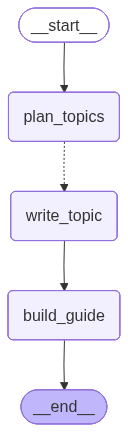

In [15]:
# Visualize the graph (renders as an image in Jupyter)
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))


In [16]:
out = graph.invoke({"subject": "Neural networks for absolute beginners"})

print("Topics the planner chose:")
for t in out["topics"]:
    print(f" - {t.title}: {t.focus}")

print("\n\n=== STUDY GUIDE ===\n")
print(out["guide"])


Topics the planner chose:
 - What are Neural Networks?: Understand the core concept of neural networks as simplified models inspired by the human brain, their purpose in learning patterns, and their general applications.
 - The Neuron: Basic Building Block: Learn about the individual 'neuron' or 'node' within a network, including inputs, weights, bias, and the role of an activation function in processing information.
 - Network Architecture: Layers: Explore how neurons are organized into different layers (input, hidden, and output) and how data flows through these layers to make predictions.
 - How Neural Networks Learn: Simplified: Grasp the basic idea of how a neural network 'learns' through iterative adjustments of its weights, involving concepts like making a prediction and comparing it to the actual outcome (error).
 - Common Terms and Concepts: Familiarize yourself with essential terminology such as training data, loss function, epochs, and the difference between supervised and u

## Takeaways

- **Orchestrator** plans → **workers** execute in parallel → **synthesizer** combines.
- `Send("node_name", payload)` dynamically spawns workers at runtime.
- `Annotated[list, operator.add]` makes LangGraph merge worker outputs by appending.
- Workers see only their own slice of work (`WorkerState`), not the whole state.

## Try it yourself

- Build an orchestrator that, given a blog-post topic, plans a list of **FAQ questions**, dispatches a worker per question to write the answer, and synthesizes an FAQ page.
